In [1]:
import os
import gc
import json
import random
import psutil
import ast
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("data")
MODEL_ID  = "HuggingFaceTB/SmolVLM-500M-Instruct"
LOG_DIR   = Path("logs")
LOG_DIR.mkdir(exist_ok=True)

BEST_CKPT         = LOG_DIR / "dora_vision_resume_epoch9_20260430_175706"
BEST_LEADERBOARD  = 0.9018
BEST_VAL_ACC      = 0.8960

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Best checkpoint: {BEST_CKPT}")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Best checkpoint: logs/dora_vision_resume_epoch9_20260430_175706


In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(ast.literal_eval)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Train: 3,109 | Val: 1,048 | Test: 1,008


In [3]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

processor.image_processor.do_image_splitting = False
processor.image_processor.size              = {"longest_edge": 512}
processor.image_processor.max_image_size    = {"longest_edge": 512}

yes_token = processor.tokenizer("Yes", add_special_tokens=False)["input_ids"][0]
no_token  = processor.tokenizer("No",  add_special_tokens=False)["input_ids"][0]
print(f"'Yes' token id: {yes_token}")
print(f"'No'  token id: {no_token}")

'Yes' token id: 10539
'No'  token id: 5230


In [4]:
def build_nli_prompt(row, choice_text, include_answer=False, max_context_chars=2000):
    text = ""
    if pd.notna(row.get("lecture", None)) and row["lecture"]:
        text += f"Background:\n{row['lecture'][:max_context_chars]}\n\n"
    if pd.notna(row.get("hint", None)) and row["hint"]:
        text += f"Passage:\n{row['hint'][:max_context_chars]}\n\n"
    text += f"Question: {row['question']}\n"
    text += f"Proposed answer: {choice_text}\n"
    text += "Is this the correct answer? Yes or No."
    prompt = f"<|im_start|>User:<image>{text}<end_of_utterance>\nAssistant:"
    if include_answer:
        prompt += " Yes" if include_answer == "yes" else " No"
    return prompt

def score_choices_nli(model, processor, image, row, choices, max_context_chars=2000):
    scores = []
    for choice in choices:
        prompt = build_nli_prompt(row, choice, include_answer=False,
                                  max_context_chars=max_context_chars)
        inputs = processor(text=[prompt], images=[image],
                          return_tensors="pt", padding=True)
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
                  for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            logits  = outputs.logits[:, -1, :]
        score = logits[0, yes_token].item() - logits[0, no_token].item()
        scores.append(score)
        del outputs, logits, inputs
        torch.cuda.empty_cache()
    return int(torch.tensor(scores).argmax().item())

def evaluate(model, val_df, data_dir, n_samples=500, seed=42):
    model.eval()
    subset  = val_df.sample(min(n_samples, len(val_df)), random_state=seed).reset_index(drop=True)
    correct = 0
    for idx in tqdm(range(len(subset)), desc="Val eval"):
        row   = subset.iloc[idx]
        image = Image.open(data_dir / row["image_path"]).convert("RGB")
        pred  = score_choices_nli(model, processor, image, row, row["choices"])
        if pred == int(row["answer"]):
            correct += 1
    acc = correct / len(subset)
    print(f"Val accuracy ({len(subset)} samples): {acc:.4f}")
    model.train()
    return acc

In [5]:
from transformers import AutoModelForVision2Seq, BitsAndBytesConfig
from peft import PeftModel

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading base model...")
base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False

print(f"Loading checkpoint: {BEST_CKPT}")
model = PeftModel.from_pretrained(base, BEST_CKPT, is_trainable=True)
model.print_trainable_parameters()

# ── Inspect connector & cross-attention layers ────────────────────────────────
print("\nConnector layers:")
for name, module in model.named_modules():
    if "connector" in name and hasattr(module, 'weight'):
        print(f"  {name}: {module.weight.shape}")

print("\nAll projection layers not already in LoRA:")
for name, module in model.named_modules():
    if hasattr(module, 'weight') and len(module.weight.shape) == 2:
        if any(kw in name for kw in ["connector", "merger", "proj"]):
            print(f"  {name}: {module.weight.shape}")

ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f"\nRAM:  {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB")
print(f"VRAM: {vram:.2f} GB")

Loading base model...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loading checkpoint: logs/dora_vision_resume_epoch9_20260430_175706
trainable params: 4,575,232 || all params: 512,057,536 || trainable%: 0.8935

Connector layers:
  base_model.model.model.connector.modality_projection.proj: torch.Size([5898240, 1])

All projection layers not already in LoRA:
  base_model.model.model.vision_model.encoder.layers.0.self_attn.k_proj: torch.Size([294912, 1])
  base_model.model.model.vision_model.encoder.layers.0.self_attn.k_proj.base_layer: torch.Size([294912, 1])
  base_model.model.model.vision_model.encoder.layers.0.self_attn.k_proj.lora_A.default: torch.Size([16, 768])
  base_model.model.model.vision_model.encoder.layers.0.self_attn.k_proj.lora_B.default: torch.Size([768, 16])
  base_model.model.model.vision_model.encoder.layers.0.self_attn.v_proj: torch.Size([294912, 1])
  base_model.model.model.vision_model.encoder.layers.0.self_attn.v_proj.base_layer: torch.Size([294912, 1])
  base_model.model.model.vision_model.encoder.layers.0.self_attn.v_proj.lora_

In [6]:
# Current params: 4,575,232
# Budget left: 5,000,000 - 4,575,232 = 424,768

current_params = 4_575_232
budget_left    = 5_000_000 - current_params
print(f"Budget remaining: {budget_left:,}")

# Connector proj: 768 × 7680 = 5,898,240 params
# LoRA on connector: r * 768 + r * 7680 = r * 8448
connector_dim_in  = 768
connector_dim_out = 7680

for r in [1, 2, 4, 8, 16, 32]:
    lora_params = r * connector_dim_in + r * connector_dim_out
    total       = current_params + lora_params
    ok          = "YES" if total < 5_000_000 else "NO"
    print(f"Connector r={r}: +{lora_params:,} params | total={total:,} | Under 5M? {ok}")

Budget remaining: 424,768
Connector r=1: +8,448 params | total=4,583,680 | Under 5M? YES
Connector r=2: +16,896 params | total=4,592,128 | Under 5M? YES
Connector r=4: +33,792 params | total=4,609,024 | Under 5M? YES
Connector r=8: +67,584 params | total=4,642,816 | Under 5M? YES
Connector r=16: +135,168 params | total=4,710,400 | Under 5M? YES
Connector r=32: +270,336 params | total=4,845,568 | Under 5M? YES


In [7]:
# ── Fresh NLI training with connector LoRA ────────────────────────────────────
from peft import LoraConfig, get_peft_model
import gc

del model
gc.collect()
torch.cuda.empty_cache()

# Fresh base model
base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        # Text model
        "q_proj", "k_proj", "v_proj", "o_proj",
        # Vision model — all 12 layers
        "model.vision_model.encoder.layers.0.self_attn.q_proj",
        "model.vision_model.encoder.layers.0.self_attn.k_proj",
        "model.vision_model.encoder.layers.0.self_attn.v_proj",
        "model.vision_model.encoder.layers.0.self_attn.out_proj",
        "model.vision_model.encoder.layers.1.self_attn.q_proj",
        "model.vision_model.encoder.layers.1.self_attn.k_proj",
        "model.vision_model.encoder.layers.1.self_attn.v_proj",
        "model.vision_model.encoder.layers.1.self_attn.out_proj",
        "model.vision_model.encoder.layers.2.self_attn.q_proj",
        "model.vision_model.encoder.layers.2.self_attn.k_proj",
        "model.vision_model.encoder.layers.2.self_attn.v_proj",
        "model.vision_model.encoder.layers.2.self_attn.out_proj",
        "model.vision_model.encoder.layers.3.self_attn.q_proj",
        "model.vision_model.encoder.layers.3.self_attn.k_proj",
        "model.vision_model.encoder.layers.3.self_attn.v_proj",
        "model.vision_model.encoder.layers.3.self_attn.out_proj",
        "model.vision_model.encoder.layers.4.self_attn.q_proj",
        "model.vision_model.encoder.layers.4.self_attn.k_proj",
        "model.vision_model.encoder.layers.4.self_attn.v_proj",
        "model.vision_model.encoder.layers.4.self_attn.out_proj",
        "model.vision_model.encoder.layers.5.self_attn.q_proj",
        "model.vision_model.encoder.layers.5.self_attn.k_proj",
        "model.vision_model.encoder.layers.5.self_attn.v_proj",
        "model.vision_model.encoder.layers.5.self_attn.out_proj",
        "model.vision_model.encoder.layers.6.self_attn.q_proj",
        "model.vision_model.encoder.layers.6.self_attn.k_proj",
        "model.vision_model.encoder.layers.6.self_attn.v_proj",
        "model.vision_model.encoder.layers.6.self_attn.out_proj",
        "model.vision_model.encoder.layers.7.self_attn.q_proj",
        "model.vision_model.encoder.layers.7.self_attn.k_proj",
        "model.vision_model.encoder.layers.7.self_attn.v_proj",
        "model.vision_model.encoder.layers.7.self_attn.out_proj",
        "model.vision_model.encoder.layers.8.self_attn.q_proj",
        "model.vision_model.encoder.layers.8.self_attn.k_proj",
        "model.vision_model.encoder.layers.8.self_attn.v_proj",
        "model.vision_model.encoder.layers.8.self_attn.out_proj",
        "model.vision_model.encoder.layers.9.self_attn.q_proj",
        "model.vision_model.encoder.layers.9.self_attn.k_proj",
        "model.vision_model.encoder.layers.9.self_attn.v_proj",
        "model.vision_model.encoder.layers.9.self_attn.out_proj",
        "model.vision_model.encoder.layers.10.self_attn.q_proj",
        "model.vision_model.encoder.layers.10.self_attn.k_proj",
        "model.vision_model.encoder.layers.10.self_attn.v_proj",
        "model.vision_model.encoder.layers.10.self_attn.out_proj",
        "model.vision_model.encoder.layers.11.self_attn.q_proj",
        "model.vision_model.encoder.layers.11.self_attn.k_proj",
        "model.vision_model.encoder.layers.11.self_attn.v_proj",
        "model.vision_model.encoder.layers.11.self_attn.out_proj",
        # Connector
        "model.connector.modality_projection.proj",
    ],
    lora_dropout=0.05,
    bias="none",
    use_dora=True,
)

model = get_peft_model(base, lora_config)
model.print_trainable_parameters()

ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f"RAM:  {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB")
print(f"VRAM: {vram:.2f} GB")

trainable params: 4,788,160 || all params: 512,270,464 || trainable%: 0.9347
RAM:  8.4/16.7 GB
VRAM: 0.75 GB


In [8]:
class NLIDataset(Dataset):
    def __init__(self, df, data_dir, max_context_chars=2000):
        self.data_dir          = data_dir
        self.max_context_chars = max_context_chars
        self.examples          = []

        for _, row in df.iterrows():
            img_path = data_dir / row["image_path"]
            for j, choice in enumerate(row["choices"]):
                is_correct = (j == int(row["answer"]))
                self.examples.append({
                    "image_path": img_path,
                    "prompt":     build_nli_prompt(
                                      row, choice,
                                      include_answer="yes" if is_correct else "no",
                                      max_context_chars=max_context_chars
                                  ),
                    "label":      1 if is_correct else 0,
                })

        print(f"NLIDataset: {len(self.examples):,} examples from {len(df):,} samples")
        labels = [ex["label"] for ex in self.examples]
        print(f"  Yes (correct):  {sum(labels):,}")
        print(f"  No (incorrect): {len(labels)-sum(labels):,}")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex  = self.examples[idx]
        img = Image.open(ex["image_path"]).convert("RGB")
        return {
            "image": img,
            "text":  ex["prompt"],
            "label": ex["label"],
        }

train_nli_ds = NLIDataset(train_df, DATA_DIR)

NLIDataset: 9,666 examples from 3,109 samples
  Yes (correct):  3,109
  No (incorrect): 6,557


In [9]:
assistant_token_ids = processor.tokenizer(
    "Assistant:", add_special_tokens=False
)["input_ids"]
print(f"'Assistant:' token ids: {assistant_token_ids}")

def collate_fn(batch):
    images  = [b["image"] for b in batch]
    texts   = [b["text"]  for b in batch]
    labels  = [b["label"] for b in batch]

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    loss_labels = inputs["input_ids"].clone()
    loss_labels[loss_labels == processor.tokenizer.pad_token_id] = -100

    for i in range(loss_labels.shape[0]):
        seq   = inputs["input_ids"][i].tolist()
        found = False
        for pos in range(len(seq) - len(assistant_token_ids)):
            if seq[pos:pos + len(assistant_token_ids)] == assistant_token_ids:
                loss_labels[i, :pos + len(assistant_token_ids)] = -100
                found = True
                break
        if not found:
            loss_labels[i, :] = -100

    inputs["labels"] = loss_labels
    return inputs, torch.tensor(labels)

# Verify
sample_batch = [train_nli_ds[i] for i in range(4)]
inputs_test, labels_test = collate_fn(sample_batch)
for i in range(4):
    label_ids  = inputs_test["labels"][i]
    valid_mask = label_ids != -100
    valid_ids  = label_ids[valid_mask]
    decoded    = processor.tokenizer.decode(valid_ids)
    print(f"Sample {i+1} | label={labels_test[i].item()} | trained on: '{decoded}'")

'Assistant:' token ids: [9519, 9531, 42]
Sample 1 | label=0 | trained on: ' No'
Sample 2 | label=0 | trained on: ' No'
Sample 3 | label=1 | trained on: ' Yes'
Sample 4 | label=1 | trained on: ' Yes'


Epoch 1:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 1 | avg loss: 0.4214
Running val eval...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.7600
Epoch 1 | val accuracy: 0.7600
Saved: logs/connector_ckpt_epoch1_20260501_130329
RAM: 9.4/16.7 GB | VRAM: 0.58 GB


Epoch 2:   0%|          | 0/2417 [00:00<?, ?it/s]

...

Val accuracy (500 samples): 0.8840
Epoch 9 | val accuracy: 0.8840
Saved: logs/connector_ckpt_epoch9_20260501_130329
RAM: 9.5/16.7 GB | VRAM: 0.58 GB


Epoch 10:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 10 | avg loss: 0.0255
Running val eval...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.8740
Epoch 10 | val accuracy: 0.8740
Saved: logs/connector_ckpt_epoch10_20260501_130329
RAM: 9.5/16.7 GB | VRAM: 0.58 GB


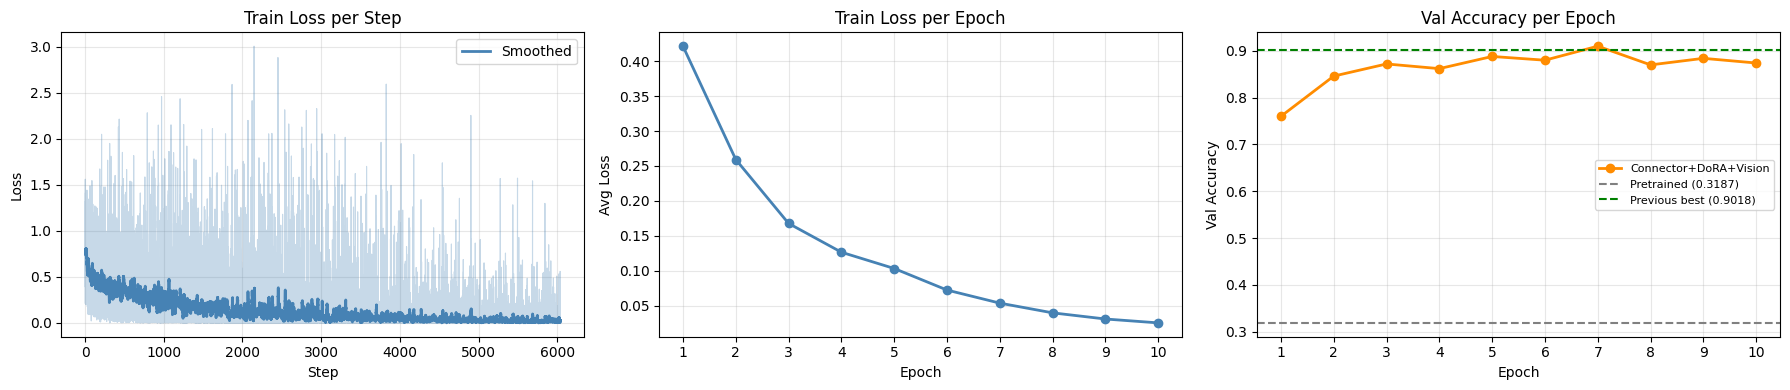


── Summary ──────────────────────────────────────────────
Epoch    Avg Loss     Val Accuracy
-----------------------------------
1        0.4214       0.7600
2        0.2593       0.8460
3        0.1678       0.8720
4        0.1266       0.8620
5        0.1033       0.8880
6        0.0725       0.8800
7        0.0538       0.9100
8        0.0398       0.8700
9        0.0311       0.8840
10       0.0255       0.8740

Best val accuracy: 0.9100 at epoch 7
Previous best leaderboard: 0.9018
Training complete.


In [10]:
from bitsandbytes.optim import PagedAdamW8bit
from transformers import get_cosine_schedule_with_warmup

EPOCHS       = 10
BATCH_SIZE   = 4
GRAD_ACCUM   = 4
LR           = 2e-4
WARMUP_RATIO = 0.03

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
log = {
    "run_id":          run_id,
    "hyperparameters": {
        "epochs":               EPOCHS,
        "batch_size":           BATCH_SIZE,
        "grad_accum":           GRAD_ACCUM,
        "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
        "lr":                   LR,
        "lora_r":               16,
        "lora_alpha":           32,
        "use_dora":             True,
        "target_modules":       "text q+k+v+o + vision all 12 layers + connector",
        "trainable_params":     4_788_160,
        "loss":                 "NLI_yes_no",
        "max_context_chars":    2000,
        "optimizer":            "PagedAdamW8bit",
    },
    "train_loss_per_step":    [],
    "train_loss_per_epoch":   [],
    "val_accuracy_per_epoch": [],
    "previous_best_leaderboard": 0.9018,
}

train_loader = DataLoader(
    train_nli_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

optimizer    = PagedAdamW8bit(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
scheduler    = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

def plot_training(log):
    steps        = [s["step"] for s in log["train_loss_per_step"]]
    losses       = [s["loss"]  for s in log["train_loss_per_step"]]
    epoch_losses = log["train_loss_per_epoch"]
    val_accs     = log["val_accuracy_per_epoch"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(steps, losses, alpha=0.3, color="steelblue", linewidth=0.8)
    if len(losses) >= 30:
        smoothed = pd.Series(losses).rolling(30).mean()
        axes[0].plot(steps, smoothed, color="steelblue", linewidth=2, label="Smoothed")
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Train Loss per Step")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(range(1, len(epoch_losses)+1), epoch_losses,
                 marker="o", color="steelblue", linewidth=2)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Avg Loss")
    axes[1].set_title("Train Loss per Epoch")
    axes[1].set_xticks(range(1, EPOCHS+1)); axes[1].grid(alpha=0.3)

    axes[2].plot(range(1, len(val_accs)+1), val_accs,
                 marker="o", color="darkorange", linewidth=2, label="Connector+DoRA+Vision")
    axes[2].axhline(y=0.3187, color="gray",  linestyle="--", label="Pretrained (0.3187)")
    axes[2].axhline(y=0.9018, color="green", linestyle="--", label="Previous best (0.9018)")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val Accuracy")
    axes[2].set_title("Val Accuracy per Epoch")
    axes[2].set_xticks(range(1, EPOCHS+1))
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(LOG_DIR / f"connector_training_{run_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Training loop ─────────────────────────────────────────────────────────────
global_step = 0
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    optimizer.zero_grad()

    for step, (inputs, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        inputs  = {k: v.to(model.device) if torch.is_tensor(v) else v
                   for k, v in inputs.items()}
        outputs = model(**inputs)
        loss    = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()

        log["train_loss_per_step"].append({
            "step":  global_step,
            "epoch": epoch + 1,
            "loss":  outputs.loss.item(),
        })

        del outputs, loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

    avg_loss = total_loss / len(train_loader)
    log["train_loss_per_epoch"].append(avg_loss)
    print(f"Epoch {epoch+1} | avg loss: {avg_loss:.4f}")

    print("Running val eval...")
    val_acc = evaluate(model, val_df, DATA_DIR, n_samples=500, seed=epoch)
    log["val_accuracy_per_epoch"].append(val_acc)
    print(f"Epoch {epoch+1} | val accuracy: {val_acc:.4f}")
    model.train()

    ckpt_path = LOG_DIR / f"connector_ckpt_epoch{epoch+1}_{run_id}"
    model.save_pretrained(ckpt_path)
    torch.save({
        "epoch":                epoch + 1,
        "global_step":          global_step,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "log":                  log,
    }, LOG_DIR / f"connector_trainer_state_epoch{epoch+1}_{run_id}.pt")
    with open(LOG_DIR / f"connector_log_{run_id}.json", "w") as f:
        json.dump(log, f, indent=2)
    print(f"Saved: {ckpt_path}")

    ram  = psutil.virtual_memory()
    vram = torch.cuda.memory_allocated() / 1e9
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

plot_training(log)
with open(LOG_DIR / f"connector_log_{run_id}.json", "w") as f:
    json.dump(log, f, indent=2)

print(f"\n── Summary ──────────────────────────────────────────────")
print(f"{'Epoch':<8} {'Avg Loss':<12} {'Val Accuracy'}")
print("-" * 35)
for i, (loss, acc) in enumerate(zip(log["train_loss_per_epoch"], log["val_accuracy_per_epoch"])):
    print(f"{i+1:<8} {loss:<12.4f} {acc:.4f}")
best_acc   = max(log["val_accuracy_per_epoch"])
best_epoch = log["val_accuracy_per_epoch"].index(best_acc) + 1
print(f"\nBest val accuracy: {best_acc:.4f} at epoch {best_epoch}")
print(f"Previous best leaderboard: 0.9018")
print("Training complete.")

In [11]:
# ── Generate submissions for epochs 5-10 ─────────────────────────────────────
from peft import PeftModel
from transformers import AutoModelForVision2Seq

for EPOCH in range(5, 11):
    print(f"\n{'='*60}")
    print(f"Generating submission for epoch {EPOCH}")
    print(f"{'='*60}")

    ckpt_path = LOG_DIR / f"connector_ckpt_epoch{EPOCH}_{run_id}"
    print(f"Loading: {ckpt_path}")

    base = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="cuda:0",
        low_cpu_mem_usage=True,
    )
    base.config.use_cache = False
    infer_model = PeftModel.from_pretrained(base, ckpt_path)
    infer_model.eval()

    test_results = []
    for idx in tqdm(range(len(test_df)), desc=f"Epoch {EPOCH} inference"):
        row    = test_df.iloc[idx]
        image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
        pred   = score_choices_nli(infer_model, processor, image, row, row["choices"])
        test_results.append({"id": row["id"], "answer": pred})

    submission_df = pd.DataFrame(test_results)
    sub_name = f"submission_connector_epoch{EPOCH}_{run_id}.csv"
    submission_df.to_csv(sub_name, index=False)
    print(f"Saved {sub_name} | Shape: {submission_df.shape}")

    del infer_model, base
    gc.collect()
    torch.cuda.empty_cache()

print("\nAll submissions generated.")


Generating submission for epoch 5
Loading: logs/connector_ckpt_epoch5_20260501_130329


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Epoch 5 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_connector_epoch5_20260501_130329.csv | Shape: (1008, 2)

Generating submission for epoch 6
Loading: logs/connector_ckpt_epoch6_20260501_130329


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...

Epoch 7 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_connector_epoch7_20260501_130329.csv | Shape: (1008, 2)

Generating submission for epoch 8
Loading: logs/connector_ckpt_epoch8_20260501_130329


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Epoch 8 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
# ── Generate image descriptions using best DoRA model ─────────────────────────
from peft import PeftModel
from transformers import AutoModelForVision2Seq
import json

DORA_CKPT = LOG_DIR / "dora_vision_resume_epoch9_20260430_175706"

print(f"Loading DoRA epoch 9 checkpoint...")
base_desc = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base_desc.config.use_cache = False
desc_model = PeftModel.from_pretrained(base_desc, DORA_CKPT)
desc_model.eval()
print("Loaded.")

def generate_image_description(model, processor, image, max_new_tokens=200):
    """Generate a general description of what's in the image."""
    prompt = "<|im_start|>User:<image>Describe everything you see in this image in detail. List all organisms, objects, arrows, labels, numbers, and any text visible.<end_of_utterance>\nAssistant:"
    inputs = processor(
        text=[prompt], images=[image],
        return_tensors="pt", padding=True
    )
    inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
              for k, v in inputs.items()}
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id,
        )
    decoded = processor.batch_decode(generated, skip_special_tokens=True)[0]
    if "Assistant:" in decoded:
        description = decoded.split("Assistant:")[-1].strip()
    else:
        description = decoded.strip()
    del generated, inputs
    torch.cuda.empty_cache()
    return description

# ── Generate descriptions for all val images ─────────────────────────────────
descriptions = []

for idx in tqdm(range(len(val_df)), desc="Generating descriptions"):
    row   = val_df.iloc[idx]
    image = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    desc  = generate_image_description(desc_model, processor, image)
    descriptions.append({
        "id":          row["id"],
        "question":    row["question"],
        "subject":     row["subject"],
        "grade":       row["grade"],
        "answer":      int(row["answer"]),
        "choices":     row["choices"],
        "description": desc,
    })

# Save to file
desc_path = LOG_DIR / "val_image_descriptions.json"
with open(desc_path, "w") as f:
    json.dump(descriptions, f, indent=2)
print(f"\nSaved {len(descriptions)} descriptions to {desc_path}")

# Print a few examples
print("\n── Sample descriptions ──────────────────────────────────────────")
for i in [0, 1, 2]:
    d = descriptions[i]
    print(f"\nID: {d['id']}")
    print(f"Q:  {d['question'][:100]}")
    print(f"Description: {d['description'][:300]}")
    print()

# Show descriptions for hard question types
print("\n── Food web descriptions ────────────────────────────────────────")
food_web_descs = [d for d in descriptions if "food web" in d["question"].lower()]
for d in food_web_descs[:3]:
    print(f"Q: {d['question'][:100]}")
    print(f"Description: {d['description'][:300]}")
    print()

print("\n── Genetics descriptions ────────────────────────────────────────")
genetics_descs = [d for d in descriptions if "homozygous" in d["question"].lower()]
for d in genetics_descs[:3]:
    print(f"Q: {d['question'][:100]}")
    print(f"Description: {d['description'][:300]}")
    print()

del desc_model, base_desc
gc.collect()
torch.cuda.empty_cache()

Loading DoRA epoch 9 checkpoint...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loaded.


Generating descriptions:   0%|          | 0/1048 [00:00<?, ?it/s]

/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


KeyboardInterrupt: 

In [29]:
# ── Few-shot prompting ────────────────────────────────────────────────────────

few_shot_prompts = {
    "membrane": (
        "<|im_start|>User:<image>"
        "Look at this osmosis diagram and count the dots on each side.\n"
        "Example answer format: 'Left side: 3 dots. Right side: 7 dots. Right side has more.'\n"
        "Now describe what you see in this image using the same format."
        "<end_of_utterance>\nAssistant:"
    ),
    "food_web": (
        "<|im_start|>User:<image>"
        "Look at this food web diagram and list the connections.\n"
        "Example answer format: 'Organisms: kelp, sea urchin, sea otter. "
        "Arrows: kelp -> sea urchin, sea urchin -> sea otter.'\n"
        "Now describe what you see in this image using the same format."
        "<end_of_utterance>\nAssistant:"
    ),
    "genetics": (
        "<|im_start|>User:<image>"
        "Look at this Punnett square and read the letters in each cell.\n"
        "Example answer format: 'Top letters: B, b. Left letters: B, b. "
        "Cells: BB, Bb, Bb, bb.'\n"
        "Now describe what you see in this image using the same format."
        "<end_of_utterance>\nAssistant:"
    ),
}

for label, samples, qtype in [
    ("MEMBRANE", membrane_samples, "membrane"),
    ("FOOD WEB", food_web_samples, "food_web"),
    ("GENETICS", genetics_samples, "genetics"),
]:
    print(f"\n{'='*60}")
    print(f"{label} — FEW-SHOT PROMPTS")
    print(f"{'='*60}")
    for _, row in samples.iterrows():
        image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
        prompt = few_shot_prompts[qtype]
        inputs = processor(text=[prompt], images=[image], return_tensors="pt", padding=True)
        inputs = {k: v.to(desc_base.device) if torch.is_tensor(v) else v
                  for k, v in inputs.items()}
        with torch.no_grad():
            generated = desc_base.generate(
                **inputs,
                max_new_tokens=150,
                do_sample=False,
                repetition_penalty=1.3,
                no_repeat_ngram_size=3,
                pad_token_id=processor.tokenizer.pad_token_id,
            )
        decoded = processor.batch_decode(generated, skip_special_tokens=True)[0]
        desc    = decoded.split("Assistant:")[-1].strip() if "Assistant:" in decoded else decoded.strip()
        del generated, inputs
        torch.cuda.empty_cache()

        print(f"Q: {row['question'][:80]}")
        print(f"Correct: {chr(65+int(row['answer']))} — {row['choices'][int(row['answer'])]}")
        print(f"Description: {desc}")
        print("-"*60)


MEMBRANE — FEW-SHOT PROMPTS


/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Q: Complete the text to describe the diagram.
Solute particles moved in both direct
Correct: B — to the left than to the right
Description: Left side:  3 dots, right side:   7 dots, both have a consistent number of green circles with white lines connecting them to form an equal but not perfectly symmetrical pattern. The left hand side is missing one dot from its total count which would be represented by line segment AB instead of A or B. However it does appear that there are two distinct patterns formed within these blue dotted shapes; however they do seem somewhat similar due to their consistency as well as being placed next to each other like twins.
------------------------------------------------------------
Q: Complete the text to describe the diagram.
Solute particles moved in both direct
Correct: B — to the right than to the left
Description: Left side:  3 dots, right side:10+8=16 dots.
------------------------------------------------------------
Q: Complete the text to describe 

/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Q: In this food web, which organism contains matter that eventually moves to the se
Correct: B — kelp
Description: Sea Otter, Kelp Forest, Starfish, Seagrass, Sea Urchins, Fish, Rockfishes, Bluefin Tuna, Black Rocks, Walleye, Yellowtail Flounder, Crappie, Shrimp, Crab, Oyster Shells, Sea Cucumber, Sea Bass, Sea Horse, Sea Grass, Sea Glass, Sea Otters, Sea Spiders, Sea Lilies, Seaweed, Sand Fence, Sea Floor, Orca, Seal, Marlin, Squid, Salmon, Chubs, Butterfly Wrasse, Eel, Manta Rider, Octopus, Clownfish, Dandelions, Butterflies, Birds, Snorkel, Sea Turtle, Sea Mouse
------------------------------------------------------------
Q: In this food web, which organism contains matter that eventually moves to the pa
Correct: B — black bear
Description: Organism: black bear, brown tree trunk, grass, orange flowers, red berries, pine cone, oak leaf, green leaves, white flower, yellow flowering plant, blueberry bush, small evergreen trees, large evergreen fir, dead wood from a forest floor with an

/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Q: What is the probability that a Cepaea snail produced by this cross will be homoz
Correct: A — 2/4
Description: Top letters: 3601289745600010020030040050060. Bottom letters: aaabbbccdddeeefffggghhhiiiiiooozzzzzzzzzz.
------------------------------------------------------------
Q: What is the probability that a Cepaea snail produced by this cross will be homoz
Correct: E — 4/4
Description: Top letters: 3601289745600010020030040050060. Bottom letters: aaabbbccdddeeefffggghhhiiiiiooozzzzzzzzzz.
------------------------------------------------------------
Q: What is the probability that a rock pocket mouse produced by this cross will be 
Correct: C — 0/4
Description: Top letters: A, a. Left letter: C, c. Cell: AB, AC, BC, CC, CA, CB, CD, DC, DD, DE, EE, EF, FF, FA, FB, FC, CF, CG, GG, HH, HT, II, III, IVA, VV, VI, VII, VIII.
------------------------------------------------------------


In [33]:
from peft import PeftModel
from transformers import AutoModelForVision2Seq

EPOCH     = 9
CKPT_PATH = LOG_DIR / f"dora_vision_resume_epoch{EPOCH}_20260430_175706"

print(f"Loading checkpoint: {CKPT_PATH}")

base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False
analysis_model = PeftModel.from_pretrained(base, CKPT_PATH)
analysis_model.eval()
print("Loaded.")

Loading checkpoint: logs/dora_vision_resume_epoch9_20260430_175706
Loaded.


In [37]:
import pytesseract
import re
from itertools import product

def extract_punnett_parents(image):
    """Extract parent alleles from edges of Punnett square."""
    w, h = image.size
    top_strip  = image.crop((0, 0, w, h//4))
    left_strip = image.crop((0, 0, w//4, h))

    top_text  = pytesseract.image_to_string(top_strip.convert("L"),  config="--psm 6")
    left_text = pytesseract.image_to_string(left_strip.convert("L"), config="--psm 6")

    # Extract alleles — single letters only
    col_alleles = re.findall(r'[A-Za-z]', top_text.strip())
    row_alleles = re.findall(r'[A-Za-z]', left_text.strip())

    return row_alleles, col_alleles

def compute_punnett_outcomes(row_alleles, col_alleles):
    """Compute all cell outcomes from parent alleles."""
    outcomes = []
    for r, c in product(row_alleles, col_alleles):
        # Sort so dominant (uppercase) comes first
        cell = "".join(sorted([r, c], key=lambda x: (x.islower(), x)))
        outcomes.append(cell)
    return outcomes

def classify_outcome(cell):
    """Classify a cell as homozygous dominant, heterozygous, or homozygous recessive."""
    if cell[0].isupper() and cell[1].isupper():
        return "homozygous_dominant"
    elif cell[0].islower() and cell[1].islower():
        return "homozygous_recessive"
    else:
        return "heterozygous"

def solve_punnett_question(question, choices, row_alleles, col_alleles):
    """
    Solve a Punnett square question given parent alleles.
    Returns the index of the correct choice.
    """
    outcomes    = compute_punnett_outcomes(row_alleles, col_alleles)
    total       = len(outcomes)
    question_lw = question.lower()

    print(f"  Outcomes: {outcomes}")
    print(f"  Total cells: {total}")

    # Count each type
    counts = {
        "homozygous_recessive":  sum(1 for o in outcomes if classify_outcome(o) == "homozygous_recessive"),
        "homozygous_dominant":   sum(1 for o in outcomes if classify_outcome(o) == "homozygous_dominant"),
        "heterozygous":          sum(1 for o in outcomes if classify_outcome(o) == "heterozygous"),
        "homozygous":            sum(1 for o in outcomes if classify_outcome(o) in ["homozygous_dominant", "homozygous_recessive"]),
        "dominant_phenotype":    sum(1 for o in outcomes if o[0].isupper()),  # at least one dominant
        "recessive_phenotype":   sum(1 for o in outcomes if o[0].islower() and o[1].islower()),
    }
    print(f"  Counts: {counts}")

    # Determine what the question is asking
    if "homozygous recessive" in question_lw:
        target_count = counts["homozygous_recessive"]
    elif "homozygous dominant" in question_lw:
        target_count = counts["homozygous_dominant"]
    elif "heterozygous" in question_lw:
        target_count = counts["heterozygous"]
    elif "homozygous" in question_lw:
        target_count = counts["homozygous"]
    elif "not have" in question_lw or "unaffected" in question_lw:
        target_count = counts["dominant_phenotype"]
    elif "have" in question_lw and ("disease" in question_lw or "disorder" in question_lw):
        target_count = counts["recessive_phenotype"]
    else:
        print("  Could not determine question type")
        return None

    # Match to choices
    target_fraction = f"{target_count}/{total}"
    target_ratio_no = f"{total - target_count}:{target_count}"  # for ratio questions
    target_ratio_yes = f"{target_count}:{total - target_count}"

    print(f"  Target fraction: {target_fraction}")
    print(f"  Target ratios: {target_ratio_no} or {target_ratio_yes}")

    for i, choice in enumerate(choices):
        choice_clean = choice.strip().replace(" ", "")
        if (choice_clean == target_fraction or
            choice_clean == target_ratio_no or
            choice_clean == target_ratio_yes):
            return i

    print(f"  No exact match found in choices: {choices}")
    return None

def score_choices_nli_with_punnett(model, processor, image, row, choices, max_context_chars=2000):
    """
    Use Punnett square solver for genetics questions,
    fall back to NLI for everything else.
    """
    question_lw = row["question"].lower()
    is_genetics = any(kw in question_lw for kw in [
        "homozygous", "heterozygous", "probability", "punnett",
        "cross", "allele", "genotype", "phenotype", "ratio",
        "huntington", "banding gene", "flower color", "stem height"
    ])

    if is_genetics:
        try:
            row_alleles, col_alleles = extract_punnett_parents(image)
            print(f"  Row alleles: {row_alleles} | Col alleles: {col_alleles}")

            if len(row_alleles) >= 2 and len(col_alleles) >= 2:
                pred = solve_punnett_question(row["question"], choices, row_alleles, col_alleles)
                if pred is not None:
                    print(f"  Punnett solver prediction: {chr(65+pred)}")
                    return pred
                else:
                    print("  Punnett solver failed — falling back to NLI")
            else:
                print(f"  Not enough alleles detected — falling back to NLI")
        except Exception as e:
            print(f"  Punnett solver error: {e} — falling back to NLI")

    # Standard NLI for non-genetics or failed genetics
    scores = []
    for choice in choices:
        prompt = build_nli_prompt(row, choice, include_answer=False,
                                  max_context_chars=max_context_chars)
        inputs = processor(text=[prompt], images=[image], return_tensors="pt", padding=True)
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            logits  = outputs.logits[:, -1, :]
        score = logits[0, yes_token].item() - logits[0, no_token].item()
        scores.append(score)
        del outputs, logits, inputs
        torch.cuda.empty_cache()

    return int(torch.tensor(scores).argmax().item())


In [38]:
# ── Full val eval with Punnett solver ─────────────────────────────────────────
analysis_model.eval()
correct       = 0
n_genetics    = 0
g_correct     = 0
n_standard    = 0
s_correct     = 0
solver_failed = 0

for idx in tqdm(range(len(val_df)), desc="Punnett solver val eval"):
    row   = val_df.iloc[idx]
    image = Image.open(DATA_DIR / row["image_path"]).convert("RGB")

    question_lw = row["question"].lower()
    is_genetics = any(kw in question_lw for kw in [
        "homozygous", "heterozygous", "probability", "punnett",
        "cross", "allele", "genotype", "phenotype", "ratio",
        "huntington", "banding gene", "flower color", "stem height"
    ])

    pred = score_choices_nli_with_punnett(
        analysis_model, processor, image, row, row["choices"]
    )

    is_correct = pred == int(row["answer"])
    correct   += is_correct

    if is_genetics:
        n_genetics += 1
        g_correct  += is_correct
    else:
        n_standard += 1
        s_correct  += is_correct

total_acc    = correct / len(val_df)
genetics_acc = g_correct / n_genetics if n_genetics > 0 else 0
standard_acc = s_correct / n_standard if n_standard > 0 else 0

print(f"\nResults:")
print(f"Overall accuracy:   {total_acc:.4f} ({correct}/{len(val_df)})")
print(f"Genetics questions: {genetics_acc:.4f} ({g_correct}/{n_genetics})")
print(f"Standard questions: {standard_acc:.4f} ({s_correct}/{n_standard})")
print(f"\nPrevious overall:   0.8960")
print(f"Difference:         {total_acc - 0.8960:+.4f}")

Punnett solver val eval:   0%|          | 0/1048 [00:00<?, ?it/s]

  Row alleles: ['B', 'b'] | Col alleles: ['b', 'b']
  Outcomes: ['Bb', 'Bb', 'bb', 'bb']
  Total cells: 4
  Counts: {'homozygous_recessive': 2, 'homozygous_dominant': 0, 'heterozygous': 2, 'homozygous': 2, 'dominant_phenotype': 2, 'recessive_phenotype': 2}
  Target fraction: 2/4
  Target ratios: 2:2 or 2:2
  Punnett solver prediction: A
  Row alleles: ['b', 'b'] | Col alleles: ['b', 'b']
  Outcomes: ['bb', 'bb', 'bb', 'bb']
  Total cells: 4
  Counts: {'homozygous_recessive': 4, 'homozygous_dominant': 0, 'heterozygous': 0, 'homozygous': 4, 'dominant_phenotype': 0, 'recessive_phenotype': 4}
  Target fraction: 4/4
  Target ratios: 0:4 or 4:0
  Punnett solver prediction: E
  Row alleles: ['M', 'M'] | Col alleles: ['n', 'a', 'i', 'n', 'a', 'i']
  Outcomes: ['Mn', 'Ma', 'Mi', 'Mn', 'Ma', 'Mi', 'Mn', 'Ma', 'Mi', 'Mn', 'Ma', 'Mi']
  Total cells: 12
  Counts: {'homozygous_recessive': 0, 'homozygous_dominant': 0, 'heterozygous': 12, 'homozygous': 0, 'dominant_phenotype': 12, 'recessive_phenotype